In [ ]:
import pandas as pd
import numpy as np

In [ ]:
dengue = pd.read_csv("/content/dengue_raw.csv")

In [ ]:
dengue.columns = ["year","week","division","cases"]

In [ ]:
dengue['cases'] = dengue['cases'].replace("null", 0)
dengue['cases'] = dengue['cases'].fillna(0)
dengue['cases'] = dengue['cases'].astype(int)

In [ ]:
dengue['division'] = dengue['division'].replace({
    "Chattogram Division (Out of CC)": "Chittagong Division (Out of CC)"
})

In [ ]:
dengue = dengue.groupby(['year','week','division'],as_index=False)['cases'].sum()

In [ ]:
dengue['week'] = dengue['week'].astype(int)
dengue = dengue.sort_values(['year','week','division']).reset_index(drop=True)

In [ ]:
dengue['division'] = dengue['division'].str.strip()

In [ ]:
print(dengue.head(20))
print(dengue['division'].unique())
print(dengue.shape)

    year  week                         division  cases
0   2025     1    Barishal Division (Out of CC)     27
1   2025     1  Chittagong Division (Out of CC)     31
2   2025     1                             DNCC     44
3   2025     1                             DSCC     43
4   2025     1       Dhaka Division (Out of CC)     50
5   2025     1      Khulna Division (Out of CC)     12
6   2025     1  Mymensingh Division (Out of CC)      7
7   2025     1    Rajshahi Division (Out of CC)      6
8   2025     1     Rangpur Division (Out of CC)      0
9   2025     1      Sylhet Division (Out of CC)      1
10  2025     2    Barishal Division (Out of CC)     51
11  2025     2  Chittagong Division (Out of CC)     56
12  2025     2                             DNCC     57
13  2025     2                             DSCC     76
14  2025     2       Dhaka Division (Out of CC)     62
15  2025     2      Khulna Division (Out of CC)     20
16  2025     2  Mymensingh Division (Out of CC)     11
17  2025  

In [ ]:
climate = pd.read_csv("/content/climate_daily.csv").dropna(how='all')

In [ ]:
print(climate.head(20))

                 name    datetime  tempmax  tempmin  temp  humidity  precip  \
0   Dhaka, Bangladesh  2025-01-01     66.1     59.0  61.8      89.1     0.0   
1   Dhaka, Bangladesh  2025-01-02     60.2     57.2  58.5      92.2     0.0   
2   Dhaka, Bangladesh  2025-01-03     62.8     56.9  59.7      90.6     0.0   
3   Dhaka, Bangladesh  2025-01-04     72.5     55.4  64.4      82.9     0.0   
4   Dhaka, Bangladesh  2025-01-05     82.4     59.0  69.2      75.6     0.0   
5   Dhaka, Bangladesh  2025-01-06     84.0     60.8  71.8      71.6     0.0   
6   Dhaka, Bangladesh  2025-01-07     78.9     62.6  70.4      66.7     0.0   
7   Dhaka, Bangladesh  2025-01-08     69.8     60.8  64.4      78.7     0.0   
8   Dhaka, Bangladesh  2025-01-09     72.7     57.2  64.0      69.6     0.0   
9   Dhaka, Bangladesh  2025-01-10     77.0     55.4  65.7      64.1     0.0   
10  Dhaka, Bangladesh  2025-01-11     80.0     55.4  67.2      63.9     0.0   
11  Dhaka, Bangladesh  2025-01-12     82.4     58.7 

In [ ]:
climate['datetime'] = pd.to_datetime(climate['datetime'])
climate['year'] = climate['datetime'].dt.year
climate['week'] = climate['datetime'].dt.isocalendar().week.astype(int)

In [ ]:
climate_selected = climate[['name','year','week','temp','tempmax','tempmin','humidity',
                            'precip','windspeed','cloudcover','uvindex']]

In [ ]:
climate_selected['division'] = climate_selected['name'].replace({
    'Dhaka, Bangladesh': 'DNCC',  # will copy later for DSCC & DHAKA
    'Chittagong, Bangladesh': 'Chittagong Division (Out of CC)',
    'Barishal, Bangladesh': 'Barishal Division (Out of CC)',
    'Khulna, Bangladesh': 'Khulna Division (Out of CC)',
    'Mymensingh, Bangladesh': 'Mymensingh Division (Out of CC)',
    'Rajshahi, Bangladesh': 'Rajshahi Division (Out of CC)',
    'Rangpur, Bangladesh': 'Rangpur Division (Out of CC)',
    'Sylhet, Bangladesh': 'Sylhet Division (Out of CC)'
})

In [ ]:
weekly_climate = climate_selected.groupby(['division','year','week'], as_index=False).agg({
    'temp':'mean',
    'tempmax':'mean',
    'tempmin':'mean',
    'humidity':'mean',
    'precip':'sum',
    'windspeed':'mean',
    'cloudcover':'mean',
    'uvindex':'mean'
})

In [ ]:
climate_DSCC = weekly_climate[weekly_climate['division']=='DNCC'].copy()
climate_DSCC['division'] = 'DSCC'

In [ ]:
climate_DHAKA = weekly_climate[weekly_climate['division']=='DNCC'].copy()
climate_DHAKA['division'] = 'DHAKA'

In [ ]:
weekly_climate = pd.concat([weekly_climate, climate_DSCC, climate_DHAKA], ignore_index=True) #weekly_climate er moddhe DNCC

In [ ]:
weekly_climate = weekly_climate[weekly_climate['division'] != 'Dhaka, Bangladesh'] #checking purpose

In [ ]:
data = pd.merge(
    dengue,
    weekly_climate,
    on=['division','year','week'],
    how='left'  # keep all dengue weeks
)

In [ ]:
print(data.head(20))

    year  week                         division  cases       temp    tempmax  \
0   2025     1    Barishal Division (Out of CC)     27  62.760000  72.100000   
1   2025     1  Chittagong Division (Out of CC)     31  66.840000  75.420000   
2   2025     1                             DNCC     44  62.720000  68.800000   
3   2025     1                             DSCC     43  62.720000  68.800000   
4   2025     1       Dhaka Division (Out of CC)     50        NaN        NaN   
5   2025     1      Khulna Division (Out of CC)     12  62.920000  72.520000   
6   2025     1  Mymensingh Division (Out of CC)      7  64.020000  75.480000   
7   2025     1    Rajshahi Division (Out of CC)      6  62.300000  73.520000   
8   2025     1     Rangpur Division (Out of CC)      0  63.340000  76.640000   
9   2025     1      Sylhet Division (Out of CC)      1  65.460000  78.940000   
10  2025     2    Barishal Division (Out of CC)     51  64.785714  78.371429   
11  2025     2  Chittagong Division (Out

In [ ]:
data = data.sort_values(['division','year','week']).reset_index(drop=True)

In [ ]:
for lag in [1,2,3,4]:
    data[f'temp_lag{lag}'] = data.groupby('division')['temp'].shift(lag)
    data[f'humidity_lag{lag}'] = data.groupby('division')['humidity'].shift(lag)
    data[f'precip_lag{lag}'] = data.groupby('division')['precip'].shift(lag)

# Drop rows with missing lag values
data = data.dropna().reset_index(drop=True)

In [ ]:
threshold = data['cases'].quantile(0.75)
data['outbreak'] = (data['cases'] > threshold).astype(int)

In [ ]:
data.to_csv("final_dengue_climate_all_divisions.csv", index=False)
print(data.head())

   year  week                       division  cases       temp    tempmax  \
0  2025     5  Barishal Division (Out of CC)     27  69.557143  80.542857   
1  2025     6  Barishal Division (Out of CC)     16  69.128571  82.414286   
2  2025     7  Barishal Division (Out of CC)     34  73.228571  85.071429   
3  2025     8  Barishal Division (Out of CC)     31  74.700000  86.142857   
4  2025     9  Barishal Division (Out of CC)     17  76.271429  88.242857   

     tempmin   humidity  precip  windspeed  ...  temp_lag2  humidity_lag2  \
0  61.185714  83.000000   0.108   6.985714  ...  66.771429      79.214286   
1  59.571429  75.785714   0.000   6.285714  ...  65.871429      81.928571   
2  63.885714  76.771429   0.028   6.542857  ...  69.557143      83.000000   
3  66.385714  80.385714   0.119   5.371429  ...  69.128571      75.785714   
4  65.757143  72.657143   0.016   7.071429  ...  73.228571      76.771429   

   precip_lag2  temp_lag3  humidity_lag3  precip_lag3  temp_lag4  \
0     

In [ ]:
#Extra

In [ ]:
#Dataset Description
num_data_points = data.shape[0]
total_columns = data.shape[1]
print(f"Number of data points: {num_data_points}")
print(f"Total columns (including target): {total_columns}")
num_input_features = total_columns - 2 #ekta case and ekta outbreak
print(f"Number of input features: {num_input_features}")

Number of data points: 394
Total columns (including target): 25
Number of input features: 23


In [ ]:
print("Data types of features:")
print(data.info())

Data types of features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 394 entries, 0 to 393
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           394 non-null    int64  
 1   week           394 non-null    int64  
 2   division       394 non-null    object 
 3   cases          394 non-null    int64  
 4   temp           394 non-null    float64
 5   tempmax        394 non-null    float64
 6   tempmin        394 non-null    float64
 7   humidity       394 non-null    float64
 8   precip         394 non-null    float64
 9   windspeed      394 non-null    float64
 10  cloudcover     394 non-null    float64
 11  uvindex        394 non-null    float64
 12  temp_lag1      394 non-null    float64
 13  humidity_lag1  394 non-null    float64
 14  precip_lag1    394 non-null    float64
 15  temp_lag2      394 non-null    float64
 16  humidity_lag2  394 non-null    float64
 17  precip_lag2    394 non-null   

In [ ]:
# Separate numerical and categorical features
numerical_features = data.select_dtypes(include=['number']).columns.tolist()
categorical_features = data.select_dtypes(include=['object']).columns.tolist()

print("Numerical Features:")
print(numerical_features)
print(f"\nThere are {len(numerical_features)} numerical features.\n")

print("Categorical Features:")
print(categorical_features)
print(f"\nThere are {len(categorical_features)} categorical features.")

Numerical Features:
['year', 'week', 'cases', 'temp', 'tempmax', 'tempmin', 'humidity', 'precip', 'windspeed', 'cloudcover', 'uvindex', 'temp_lag1', 'humidity_lag1', 'precip_lag1', 'temp_lag2', 'humidity_lag2', 'precip_lag2', 'temp_lag3', 'humidity_lag3', 'precip_lag3', 'temp_lag4', 'humidity_lag4', 'precip_lag4', 'outbreak']

There are 24 numerical features.

Categorical Features:
['division']

There are 1 categorical features.


In [ ]:
# Check for Null/Missing Values
print("Missing Values")
print(data.isnull().sum())

Missing Values
year             0
week             0
division         0
cases            0
temp             0
tempmax          0
tempmin          0
humidity         0
precip           0
windspeed        0
cloudcover       0
uvindex          0
temp_lag1        0
humidity_lag1    0
precip_lag1      0
temp_lag2        0
humidity_lag2    0
precip_lag2      0
temp_lag3        0
humidity_lag3    0
precip_lag3      0
temp_lag4        0
humidity_lag4    0
precip_lag4      0
outbreak         0
dtype: int64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Correlation Analysis


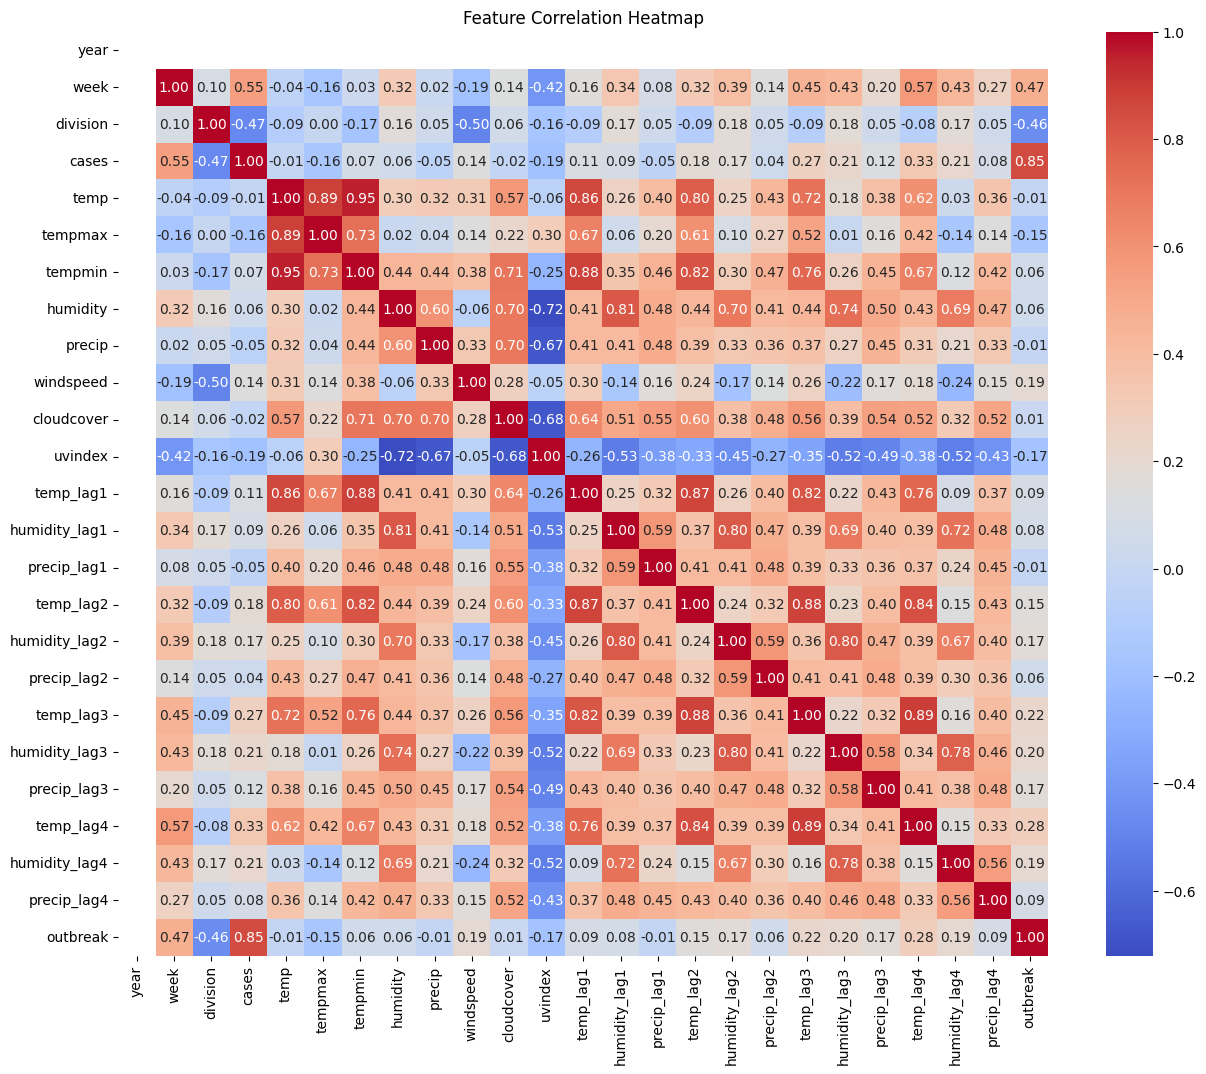

In [ ]:
# Correlation Analysis
print("Correlation Analysis")
df_encoded = data.copy()

from sklearn.preprocessing import LabelEncoder
for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        le = LabelEncoder()
        df_encoded[column] = le.fit_transform(df_encoded[column])

correlation_matrix = df_encoded.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
#Imbalanced Dataset Analysis
print("Imbalanced Dataset Analysis")
class_counts = data['outbreak'].value_counts()
print("Count of each class:")
print(class_counts)

Imbalanced Dataset Analysis
Count of each class:
outbreak
0    296
1     98
Name: count, dtype: int64


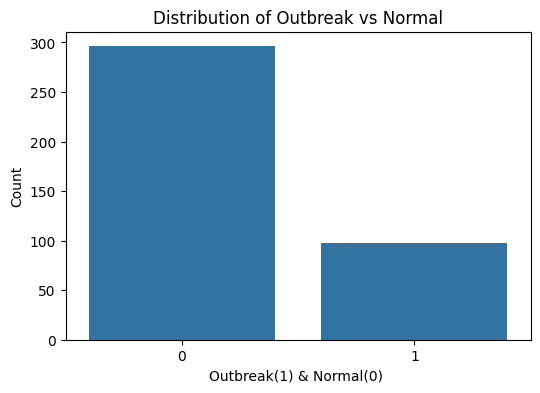

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='outbreak', data=data)
plt.title('Distribution of Outbreak vs Normal')
plt.xlabel('Outbreak(1) & Normal(0) ')
plt.ylabel('Count')
plt.show()

In [ ]:
# Regression based target
y_reg = data['cases']

# Classification based target
y_clf = data['outbreak']

feature_cols = [
    'temp','tempmax','tempmin','humidity','precip','windspeed','cloudcover','uvindex',
    'temp_lag1','temp_lag2','temp_lag3','temp_lag4',
    'humidity_lag1','humidity_lag2','humidity_lag3','humidity_lag4',
    'precip_lag1','precip_lag2','precip_lag3','precip_lag4'
]

X = data[feature_cols]

In [ ]:
from sklearn.model_selection import train_test_split

split = int(len(data)*0.8)
X_train, X_test = X[:split], X[split:] #Split features X
y_train_reg, y_test_reg = y_reg[:split], y_reg[split:] #Split targets regression
y_train_clf, y_test_clf = y_clf[:split], y_clf[split:] #Split targets classification

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train_reg)

y_pred_reg = rf_reg.predict(X_test)

print("Regression R2:", r2_score(y_test_reg, y_pred_reg))
print("Regression RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))

Regression R2: -12.413437685067082
Regression RMSE: 283.61099303590396


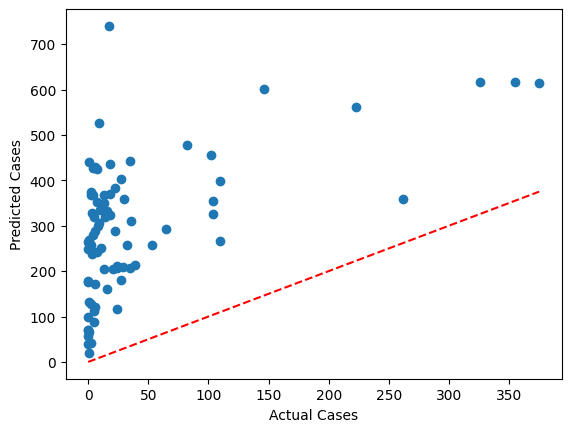

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test_reg, y_pred_reg)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.xlabel('Actual Cases')
plt.ylabel('Predicted Cases')
plt.show()

In [ ]:
feature_info = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_reg.feature_importances_})
feature_info = feature_info.sort_values(by='Importance', ascending=False)
print(feature_info)

          Feature  Importance
7         uvindex    0.168325
4          precip    0.093791
3        humidity    0.092901
11      temp_lag4    0.066119
13  humidity_lag2    0.063311
10      temp_lag3    0.058387
1         tempmax    0.050229
14  humidity_lag3    0.049876
6      cloudcover    0.048143
9       temp_lag2    0.046935
19    precip_lag4    0.044383
8       temp_lag1    0.035366
15  humidity_lag4    0.034291
5       windspeed    0.027555
12  humidity_lag1    0.025872
16    precip_lag1    0.022345
18    precip_lag3    0.020032
0            temp    0.018256
17    precip_lag2    0.016976
2         tempmin    0.016905


##Edited

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import precision_score, recall_score

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train_clf)

y_pred_clf = rf_clf.predict(X_test)
y_pred_prob = rf_clf.predict_proba(X_test)[:,1]

print("Classification Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print("Precision:", precision_score(y_test_clf, y_pred_clf))
print("Recall:", recall_score(y_test_clf, y_pred_clf))
print("F1 Score:", f1_score(y_test_clf, y_pred_clf))
print("ROC AUC:", roc_auc_score(y_test_clf, y_pred_prob))
y_pred_prob_balanced = rf_clf.predict_proba(X_test)[:,1]

print("Min probability:", y_pred_prob_balanced.min())
print("Max probability:", y_pred_prob_balanced.max())
print("Mean probability:", y_pred_prob_balanced.mean())
print()
print("Probabilities for ACTUAL outbreak rows:")
print(y_pred_prob_balanced[y_test_clf.values == 1])
print()
print("Probabilities for ACTUAL normal rows (first 20):")
print(y_pred_prob_balanced[y_test_clf.values == 0][:20])

Classification Accuracy: 0.8734177215189873
Precision: 0.23076923076923078
Recall: 1.0
F1 Score: 0.375
ROC AUC: 0.9342105263157895
Min probability: 0.025
Max probability: 0.8441121495327103
Mean probability: 0.31069211002953834

Probabilities for ACTUAL outbreak rows:
[0.795      0.57       0.55268293]

Probabilities for ACTUAL normal rows (first 20):
[0.72657751 0.68       0.295      0.13       0.035      0.03
 0.04268293 0.055      0.11       0.055      0.09768293 0.46453796
 0.16329202 0.16193832 0.47142167 0.18       0.24096181 0.16638901
 0.27087871 0.21698413]


#extra

## 1. Check feature importances - are lag features actually doing the work?
## Just to check

In [ ]:
# 1. Check feature importances - are lag features actually doing the work?
import pandas as pd
importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)
print()

# 2. Compare a real test-set row that scored LOW vs one that scored HIGH
# Find index of a low-prob normal row and the highest-prob outbreak row
import numpy as np
low_idx = np.where((y_test_clf.values == 0) & (y_pred_prob < 0.05))[0]
high_idx = np.where((y_test_clf.values == 1) & (y_pred_prob > 0.7))[0]

print("LOW-risk real test row (raw, unscaled):")
print(X_test.iloc[low_idx[0]])
print()
print("HIGH-risk real test row (raw, unscaled):")
print(X_test.iloc[high_idx[0]])

temp_lag4        0.106916
uvindex          0.094942
tempmax          0.085919
temp_lag2        0.079519
humidity_lag4    0.062335
temp_lag3        0.056005
precip_lag4      0.051933
tempmin          0.049621
humidity_lag2    0.047191
humidity_lag3    0.042661
cloudcover       0.038486
temp             0.037883
precip           0.037191
temp_lag1        0.036909
humidity         0.035401
windspeed        0.031961
humidity_lag1    0.030407
precip_lag3      0.030342
precip_lag1      0.024625
precip_lag2      0.019752
dtype: float64

LOW-risk real test row (raw, unscaled):
temp             64.914286
tempmax          76.728571
tempmin          55.571429
humidity         85.914286
precip            0.004000
windspeed         5.228571
cloudcover       36.414286
uvindex           6.857143
temp_lag1        61.828571
temp_lag2        66.157143
temp_lag3        65.642857
temp_lag4        63.340000
humidity_lag1    89.314286
humidity_lag2    79.285714
humidity_lag3    78.714286
humidity_lag4    85

In [ ]:
import xgboost as xgb

# Regression
xgb_reg = xgb.XGBRegressor(n_estimators=200, random_state=42)
xgb_reg.fit(X_train, y_train_reg)
y_pred_reg_xgb = xgb_reg.predict(X_test)

# Classification
xgb_clf = xgb.XGBClassifier(n_estimators=200, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train, y_train_clf)
y_pred_clf_xgb = xgb_clf.predict(X_test)
y_pred_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:44:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
r2 = r2_score(y_test_reg, y_pred_reg_xgb)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_xgb))

print("XGBoost Regression R²:", r2)
print("XGBoost Regression RMSE:", rmse)

XGBoost Regression R²: -8.875349044799805
XGBoost Regression RMSE: 243.34882852347985


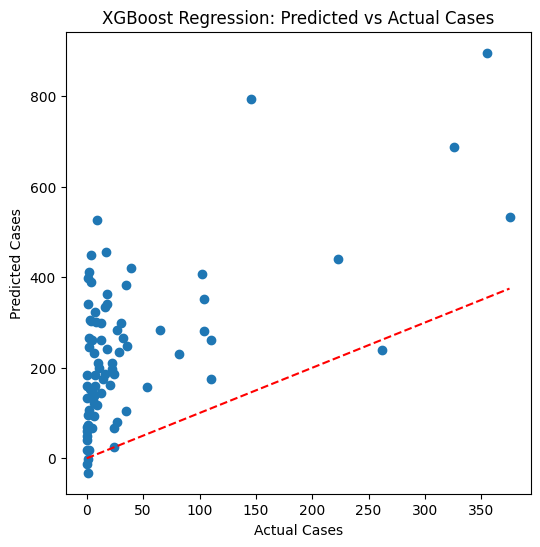

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg_xgb)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--')
plt.xlabel("Actual Cases")
plt.ylabel("Predicted Cases")
plt.title("XGBoost Regression: Predicted vs Actual Cases")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
acc = accuracy_score(y_test_clf, y_pred_clf_xgb)
roc_auc = roc_auc_score(y_test_clf, y_pred_prob_xgb)

print("XGBoost Classification Accuracy:", acc)
print("XGBoost Classification ROC-AUC:", roc_auc)

cm = confusion_matrix(y_test_clf, y_pred_clf_xgb)
print("Confusion Matrix:\n", cm)

# Detailed report
print(classification_report(y_test_clf, y_pred_clf_xgb))

XGBoost Classification Accuracy: 0.6835443037974683
XGBoost Classification ROC-AUC: 0.9429824561403509
Confusion Matrix:
 [[51 25]
 [ 0  3]]
              precision    recall  f1-score   support

           0       1.00      0.67      0.80        76
           1       0.11      1.00      0.19         3

    accuracy                           0.68        79
   macro avg       0.55      0.84      0.50        79
weighted avg       0.97      0.68      0.78        79



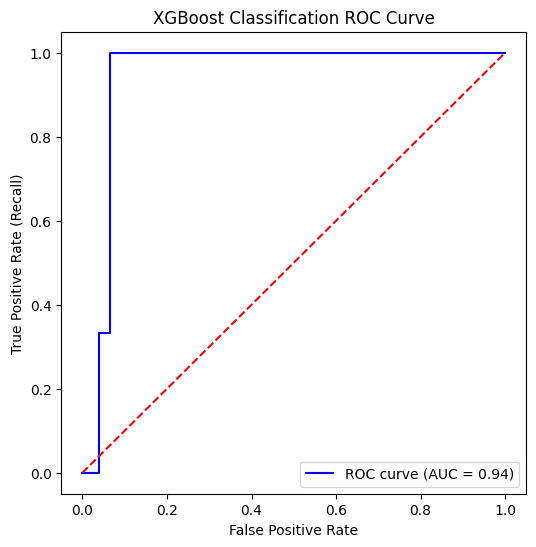

In [ ]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test_clf, y_pred_prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('XGBoost Classification ROC Curve')
plt.legend(loc='lower right')
plt.show()

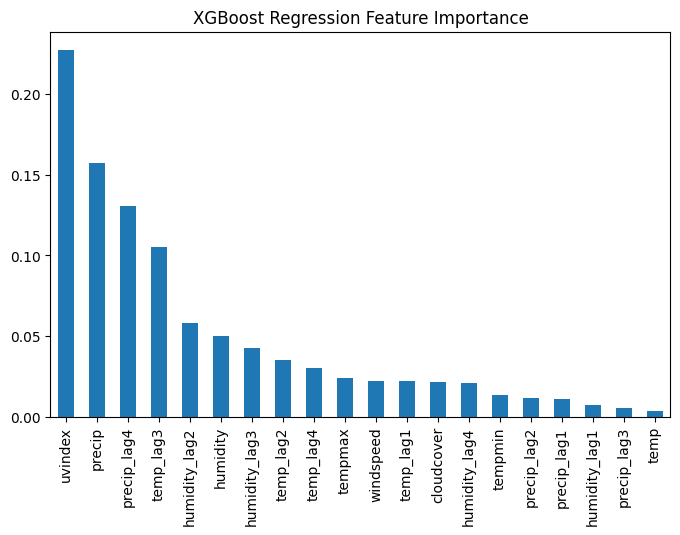

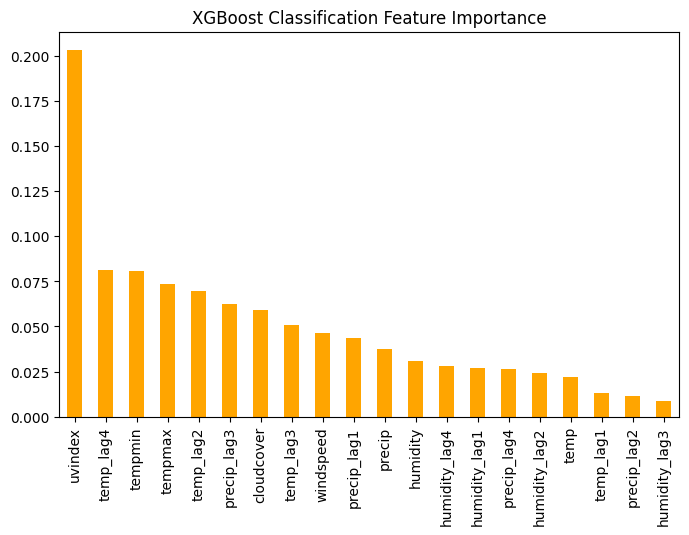

In [ ]:
# Regression importance
importance_reg = pd.Series(xgb_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance_reg.plot(kind='bar')
plt.title("XGBoost Regression Feature Importance")
plt.show()

# Classification importance
importance_clf = pd.Series(xgb_clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importance_clf.plot(kind='bar', color='orange')
plt.title("XGBoost Classification Feature Importance")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import random
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

model_reg = Sequential()
model_reg.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_reg.add(Dropout(0.2))
model_reg.add(Dense(1))

model_reg.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_reg = model_reg.fit(
    X_train_lstm, y_train_reg,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 172262.6719 - val_loss: 27384.1738
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 171949.4375 - val_loss: 27222.0586
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 171530.3438 - val_loss: 27000.9922
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 170962.9375 - val_loss: 26718.1660
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 170254.9062 - val_loss: 26388.4492
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 169470.1875 - val_loss: 26032.8535
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 168618.3438 - val_loss: 25669.8340
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 167816.4375 - val_loss: 25315.0918
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 166876.3281 - val_loss: 24973.2031
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 166157.1719 - val_loss: 24652.8809
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss

In [ ]:
y_pred_reg_lstm = model_reg.predict(X_test_lstm)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_lstm))
r2 = r2_score(y_test_reg, y_pred_reg_lstm)

print("LSTM Regression RMSE:", rmse)
print("LSTM Regression R²:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
LSTM Regression RMSE: 90.49920417899402
LSTM Regression R²: -0.3657885789871216


In [ ]:
model_clf = Sequential()
model_clf.add(LSTM(64, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False))
model_clf.add(Dropout(0.2))
model_clf.add(Dense(1, activation='sigmoid'))

model_clf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history_clf = model_clf.fit(
    X_train_lstm, y_train_clf,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6190 - loss: 0.6812 - val_accuracy: 0.9206 - val_loss: 0.6086
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.6589 - val_accuracy: 0.9206 - val_loss: 0.5363
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.6531 - val_accuracy: 0.9206 - val_loss: 0.5112
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.6484 - val_accuracy: 0.9206 - val_loss: 0.5120
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.6427 - val_accuracy: 0.9206 - val_loss: 0.5133
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.6362 - val_accuracy: 0.9206 - val_loss: 0.5160
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.6295 - val_accuracy: 0.9206 - val_loss: 0.5151
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6508 - loss: 0.6229 - val_accuracy: 0.9206 - 

In [ ]:
y_pred_clf_lstm = (model_clf.predict(X_test_lstm) > 0.5).astype(int)
y_pred_prob_lstm = model_clf.predict(X_test_lstm)

acc = accuracy_score(y_test_clf, y_pred_clf_lstm)
roc_auc = roc_auc_score(y_test_clf, y_pred_prob_lstm)

print("LSTM Classification Accuracy:", acc)
print("LSTM Classification ROC-AUC:", roc_auc)
print(confusion_matrix(y_test_clf, y_pred_clf_lstm))
print(classification_report(y_test_clf, y_pred_clf_lstm))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
LSTM Classification Accuracy: 0.9620253164556962
LSTM Classification ROC-AUC: 0.631578947368421
[[76  0]
 [ 3  0]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        76
           1       0.00      0.00      0.00         3

    accuracy                           0.96        79
   macro avg       0.48      0.50      0.49        79
weighted avg       0.93      0.96      0.94        79



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
results_reg = []

results_reg.append([
    "Random Forest",
    np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)),
    r2_score(y_test_reg, y_pred_reg)
])

results_reg.append([
    "XGBoost",
    np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_xgb)),
    r2_score(y_test_reg, y_pred_reg_xgb)
])

results_reg.append([
    "LSTM",
    np.sqrt(mean_squared_error(y_test_reg, y_pred_reg_lstm)),
    r2_score(y_test_reg, y_pred_reg_lstm)
])

df_reg = pd.DataFrame(results_reg, columns=["Model", "RMSE", "R²"])
print(df_reg)

           Model        RMSE         R²
0  Random Forest  283.610993 -12.413438
1        XGBoost  243.348829  -8.875349
2           LSTM   90.499204  -0.365789


In [ ]:
results_clf = []

def add_result(name, y_true, y_pred, y_prob):
    results_clf.append([name,
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        roc_auc_score(y_true, y_prob)
    ])

add_result("Random Forest", y_test_clf, y_pred_clf, y_pred_prob)
add_result("XGBoost", y_test_clf, y_pred_clf_xgb, y_pred_prob_xgb)
add_result("LSTM", y_test_clf, y_pred_clf_lstm, y_pred_prob_lstm)

df_clf = pd.DataFrame(results_clf, columns=["Model","Accuracy","Precision","Recall","F1","ROC-AUC"])
print(df_clf)


           Model  Accuracy  Precision  Recall        F1   ROC-AUC
0  Random Forest  0.873418   0.230769     1.0  0.375000  0.934211
1        XGBoost  0.683544   0.107143     1.0  0.193548  0.942982
2           LSTM  0.962025   0.000000     0.0  0.000000  0.631579


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


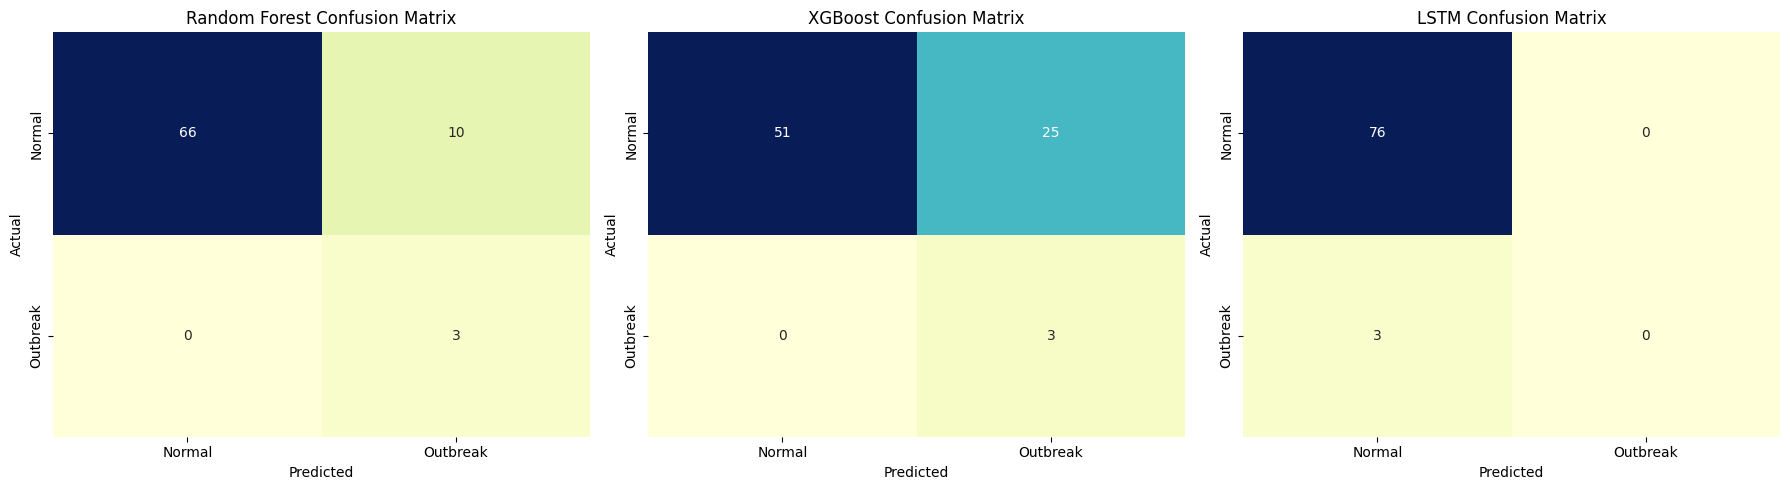

In [ ]:
models = ['Random Forest', 'XGBoost', 'LSTM']
predictions = [y_pred_clf, y_pred_clf_xgb, y_pred_clf_lstm]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, pred) in enumerate(zip(models, predictions)):
    cm = confusion_matrix(y_test_clf, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', ax=axes[i],
                xticklabels=['Normal', 'Outbreak'],
                yticklabels=['Normal', 'Outbreak'],
                cbar=False)
    axes[i].set_title(f'{name} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

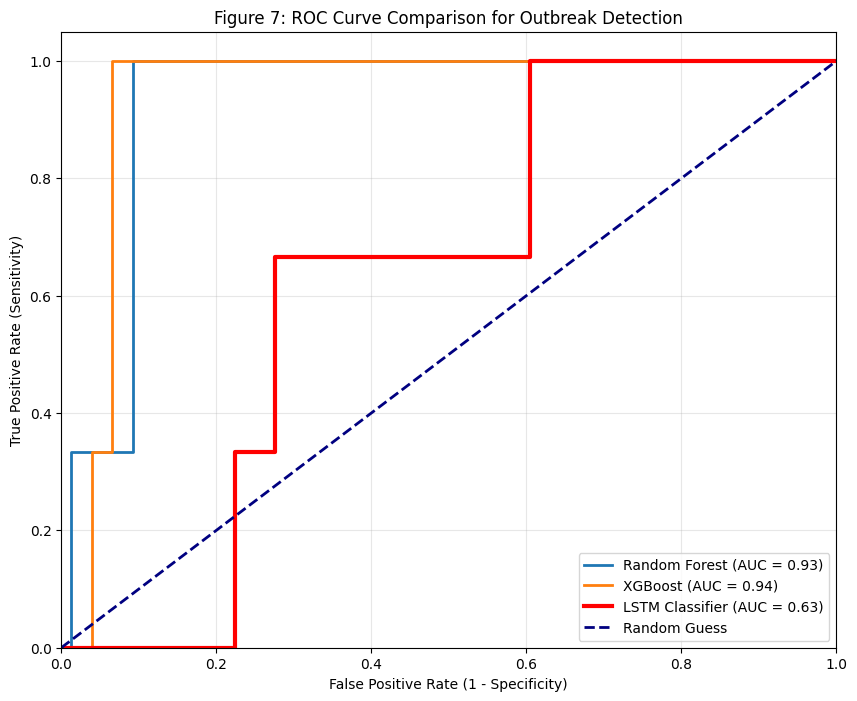

In [ ]:
plt.figure(figsize=(10, 8))

fpr_rf, tpr_rf, _ = roc_curve(y_test_clf, y_pred_prob)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

fpr_xgb, tpr_xgb, _ = roc_curve(y_test_clf, y_pred_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')

fpr_lstm, tpr_lstm, _ = roc_curve(y_test_clf, y_pred_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
plt.plot(fpr_lstm, tpr_lstm, lw=3, color='red', label=f'LSTM Classifier (AUC = {roc_auc_lstm:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Figure 7: ROC Curve Comparison for Outbreak Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Model Performance Comparison

In [ ]:
print('Classification Model Performance:')
display(df_clf)

print('\nRegression Model Performance:')
display(df_reg)

Classification Model Performance:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.873418,0.230769,1.0,0.375000,0.934211
1,XGBoost,0.683544,0.107143,1.0,0.193548,0.942982
2,LSTM,0.962025,0.000000,0.0,0.000000,0.631579



Regression Model Performance:


,Model,RMSE,R²
0,Random Forest,283.610993,-12.413438
1,XGBoost,243.348829,-8.875349
2,LSTM,90.499204,-0.365789


In [ ]:
import joblib
import pickle
import os
from google.colab import files

# Create a models folder in Colab
os.makedirs('models', exist_ok=True)

# Save all models
joblib.dump(rf_clf, 'models/rf_classifier.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
with open('models/feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
model_reg.save('models/lstm_regressor.h5')

print("✅ Models saved locally in Colab")

# Download models to your computer
!zip -r models.zip models
files.download('models.zip')

import joblib
import os
from google.colab import files

os.makedirs('models', exist_ok=True)
joblib.dump(rf_clf, 'models/rf_classifier.pkl')

print("✅ New rf_classifier.pkl saved")
print("class_weight:", rf_clf.class_weight)

files.download('models/rf_classifier.pkl')

✅ Models saved locally in Colab
  adding: models/ (stored 0%)
  adding: models/lstm_regressor.h5 (deflated 60%)
  adding: models/feature_columns.pkl (deflated 50%)
  adding: models/rf_classifier.pkl (deflated 76%)
  adding: models/scaler.pkl (deflated 51%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ New rf_classifier.pkl saved
class_weight: balanced


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def c_to_f(c): return c * 9 / 5 + 32
def mm_to_in(mm): return mm / 25.4
def kmh_to_mph(kmh): return kmh / 1.60934

def score_scenario(temp, humidity, precip, label):
    row = {
        'temp': c_to_f(temp), 'tempmax': c_to_f(temp + 5), 'tempmin': c_to_f(temp - 5),
        'humidity': humidity, 'precip': mm_to_in(precip), 'windspeed': kmh_to_mph(15),
        'cloudcover': 50, 'uvindex': 7,
    }
    # "Stable" trend — same logic the app uses when trend = Stable
    for i in range(1, 5):
        row[f'temp_lag{i}'] = c_to_f(temp)
        row[f'humidity_lag{i}'] = humidity
        row[f'precip_lag{i}'] = mm_to_in(precip)

    df = pd.DataFrame([row])[feature_cols]
    scaled = scaler.transform(df)
    prob = rf_clf.predict_proba(scaled)[0][1]
    print(f"{label:35s} prob={prob:.3f}")

score_scenario(20, 40, 0, "Cool/dry (20C/40%/0mm)")
score_scenario(30, 85, 120, "Warm/humid/rain (30C/85%/120mm)")
score_scenario(32, 92, 220, "Heavier monsoon (32C/92%/220mm)")
score_scenario(33, 98, 350, "Extreme wet (33C/98%/350mm)")
score_scenario(40, 35, 0, "Dry heat (40C/35%/0mm)")

print("X_train columns:", list(X_train.columns))
print()
print("feature_cols:", feature_cols)
print()
print("Are they in the same order?", list(X_train.columns) == feature_cols)
print()
print("scaler.feature_names_in_:", list(scaler.feature_names_in_) if hasattr(scaler, 'feature_names_in_') else "N/A — scaler has no feature names")

Cool/dry (20C/40%/0mm)              prob=0.265
Warm/humid/rain (30C/85%/120mm)     prob=0.235
Heavier monsoon (32C/92%/220mm)     prob=0.230
Extreme wet (33C/98%/350mm)         prob=0.235
Dry heat (40C/35%/0mm)              prob=0.265
X_train columns: ['temp', 'tempmax', 'tempmin', 'humidity', 'precip', 'windspeed', 'cloudcover', 'uvindex', 'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag4', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3', 'humidity_lag4', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4']

feature_cols: ['temp', 'tempmax', 'tempmin', 'humidity', 'precip', 'windspeed', 'cloudcover', 'uvindex', 'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag4', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3', 'humidity_lag4', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4']

Are they in the same order? True

scaler.feature_names_in_: ['temp', 'tempmax', 'tempmin', 'humidity', 'precip', 'windspeed', 'cloudcover', 'uvindex', 'temp_lag1', 'temp_lag2', 'temp_lag3', 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np

# Correlation of raw climate features with outbreak label
df_check = X_train.copy()
df_check['outbreak'] = y_train_clf.values

corr = df_check.corr()['outbreak'].drop('outbreak').sort_values(key=abs, ascending=False)
print("Correlation with outbreak label:")
print(corr)
print()
print("Total training rows:", len(X_train))
print("Outbreak rate in training set:", y_train_clf.mean())

Correlation with outbreak label:
temp_lag4        0.309891
humidity_lag3    0.287641
humidity_lag4    0.281249
uvindex         -0.270030
precip_lag3      0.254058
humidity_lag2    0.249336
temp_lag3        0.231145
tempmax         -0.196321
precip_lag4      0.156704
temp_lag2        0.148917
humidity_lag1    0.148460
humidity         0.132921
precip_lag2      0.115139
windspeed        0.113166
temp_lag1        0.089161
cloudcover       0.068170
tempmin          0.039387
temp            -0.034715
precip           0.030513
precip_lag1      0.028054
Name: outbreak, dtype: float64

Total training rows: 315
Outbreak rate in training set: 0.30158730158730157


In [ ]:
# --- Feature engineering fix: add cumulative/rolling climate signals ---

# Build smoothed features from the lag columns (still purely real data, no synthetic rows)
df_train_fe = X_train.copy()
df_test_fe = X_test.copy()

for df_fe in [df_train_fe, df_test_fe]:
    df_fe['precip_roll4'] = df_fe[['precip_lag1','precip_lag2','precip_lag3','precip_lag4']].mean(axis=1)
    df_fe['humidity_roll4'] = df_fe[['humidity_lag1','humidity_lag2','humidity_lag3','humidity_lag4']].mean(axis=1)
    df_fe['temp_roll4'] = df_fe[['temp_lag1','temp_lag2','temp_lag3','temp_lag4']].mean(axis=1)

feature_cols_v2 = feature_cols + ['precip_roll4', 'humidity_roll4', 'temp_roll4']

X_train_v2 = df_train_fe[feature_cols_v2]
X_test_v2 = df_test_fe[feature_cols_v2]

# Retrain with same settings, new features
rf_clf_v2 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', max_depth=8, min_samples_leaf=3)
rf_clf_v2.fit(X_train_v2, y_train_clf)

y_pred_v2 = rf_clf_v2.predict(X_test_v2)
y_prob_v2 = rf_clf_v2.predict_proba(X_test_v2)[:,1]

print("Accuracy:", accuracy_score(y_test_clf, y_pred_v2))
print("Precision:", precision_score(y_test_clf, y_pred_v2))
print("Recall:", recall_score(y_test_clf, y_pred_v2))
print("F1:", f1_score(y_test_clf, y_pred_v2))
print("ROC AUC:", roc_auc_score(y_test_clf, y_prob_v2))
print()

importances_v2 = pd.Series(rf_clf_v2.feature_importances_, index=feature_cols_v2).sort_values(ascending=False)
print(importances_v2.head(10))

Accuracy: 0.6329113924050633
Precision: 0.09375
Recall: 1.0
F1: 0.17142857142857143
ROC AUC: 0.9473684210526316

uvindex          0.092104
temp_roll4       0.076526
temp_lag4        0.076256
temp_lag2        0.072584
tempmax          0.072199
precip_lag4      0.057867
temp_lag3        0.057129
humidity_lag4    0.055100
tempmin          0.043164
temp             0.038200
dtype: float64


In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test_clf, y_prob_v2)

# Find threshold that gives best F1 balance
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = f1_scores[:-1].argmax()  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"At this threshold -> Precision: {precisions[best_idx]:.3f}, Recall: {recalls[best_idx]:.3f}, F1: {f1_scores[best_idx]:.3f}")
print()

# Show a few candidate thresholds for comparison
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    preds_t = (y_prob_v2 >= t).astype(int)
    print(f"Threshold {t}: Precision={precision_score(y_test_clf, preds_t, zero_division=0):.3f}, "
          f"Recall={recall_score(y_test_clf, preds_t, zero_division=0):.3f}, "
          f"F1={f1_score(y_test_clf, preds_t, zero_division=0):.3f}")

Best threshold: 0.724
At this threshold -> Precision: 0.429, Recall: 1.000, F1: 0.600

Threshold 0.3: Precision=0.059, Recall=1.000, F1=0.111
Threshold 0.4: Precision=0.075, Recall=1.000, F1=0.140
Threshold 0.5: Precision=0.094, Recall=1.000, F1=0.171
Threshold 0.6: Precision=0.188, Recall=1.000, F1=0.316
Threshold 0.7: Precision=0.429, Recall=1.000, F1=0.600


In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

BEST_THRESHOLD = 0.724

# Save model, scaler-compatible feature list, and threshold together
joblib.dump(rf_clf_v2, 'models/rf_classifier_v2.pkl')
joblib.dump(feature_cols_v2, 'models/feature_cols_v2.pkl')
joblib.dump(BEST_THRESHOLD, 'models/rf_threshold.pkl')

print("Saved model, feature list, and threshold.")
print("File sizes:")
for f in ['models/rf_classifier_v2.pkl', 'models/feature_cols_v2.pkl', 'models/rf_threshold.pkl']:
    print(f, "->", os.path.getsize(f), "bytes")

# Sanity check: reload from disk immediately and re-verify predictions match
rf_reloaded = joblib.load('models/rf_classifier_v2.pkl')
y_prob_reloaded = rf_reloaded.predict_proba(X_test_v2)[:,1]
import numpy as np
print()
print("Match after reload:", np.allclose(y_prob_reloaded, y_prob_v2))

Saved model, feature list, and threshold.
File sizes:
models/rf_classifier_v2.pkl -> 811113 bytes
models/feature_cols_v2.pkl -> 311 bytes
models/rf_threshold.pkl -> 21 bytes

Match after reload: True


In [ ]:
from google.colab import files
import time

for fname in ['models/rf_classifier_v2.pkl', 'models/feature_cols_v2.pkl', 'models/rf_threshold.pkl']:
    print(f"Downloading {fname} ...")
    files.download(fname)
    time.sleep(2)  # small pause so each download fully registers before the next starts

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(type(scaler))

<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import numpy as np

# Fit a NEW scaler on the 23-column feature set (same class as before)
scaler_v2 = MinMaxScaler()
scaler_v2.fit(X_train_v2)

# Save it
joblib.dump(scaler_v2, 'models/scaler_v2.pkl')

print("Saved scaler_v2.pkl")
print("File size:", __import__('os').path.getsize('models/scaler_v2.pkl'), "bytes")
print("Features it expects:", list(scaler_v2.feature_names_in_))
print("Number of features:", scaler_v2.n_features_in_)

# Sanity check: reload and confirm transform output matches
scaler_v2_reloaded = joblib.load('models/scaler_v2.pkl')
match = np.allclose(
    scaler_v2.transform(X_test_v2),
    scaler_v2_reloaded.transform(X_test_v2)
)
print("Match after reload:", match)

Saved scaler_v2.pkl
File size: 2143 bytes
Features it expects: ['temp', 'tempmax', 'tempmin', 'humidity', 'precip', 'windspeed', 'cloudcover', 'uvindex', 'temp_lag1', 'temp_lag2', 'temp_lag3', 'temp_lag4', 'humidity_lag1', 'humidity_lag2', 'humidity_lag3', 'humidity_lag4', 'precip_lag1', 'precip_lag2', 'precip_lag3', 'precip_lag4', 'precip_roll4', 'humidity_roll4', 'temp_roll4']
Number of features: 23
Match after reload: True


In [ ]:
from google.colab import files
import time

print("Downloading scaler_v2.pkl ...")
files.download('models/scaler_v2.pkl')
time.sleep(2)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def score_scenario_v2(temp, humidity, precip, label):
    row = {
        'temp': c_to_f(temp), 'tempmax': c_to_f(temp + 5), 'tempmin': c_to_f(temp - 5),
        'humidity': humidity, 'precip': mm_to_in(precip), 'windspeed': kmh_to_mph(15),
        'cloudcover': 50, 'uvindex': 7,
    }
    # "Stable" trend — same logic the app uses when trend = Stable
    for i in range(1, 5):
        row[f'temp_lag{i}'] = c_to_f(temp)
        row[f'humidity_lag{i}'] = humidity
        row[f'precip_lag{i}'] = mm_to_in(precip)

    df = pd.DataFrame([row])
    df['precip_roll4'] = df[['precip_lag1','precip_lag2','precip_lag3','precip_lag4']].mean(axis=1)
    df['humidity_roll4'] = df[['humidity_lag1','humidity_lag2','humidity_lag3','humidity_lag4']].mean(axis=1)
    df['temp_roll4'] = df[['temp_lag1','temp_lag2','temp_lag3','temp_lag4']].mean(axis=1)

    df = df[feature_cols_v2]
    scaled = scaler_v2.transform(df)
    prob = rf_clf_v2.predict_proba(scaled)[0][1]
    print(f"{label:35s} prob={prob:.3f}")

score_scenario_v2(20, 40, 0, "Cool/dry (20C/40%/0mm)")
score_scenario_v2(30, 85, 120, "Warm/humid/rain (30C/85%/120mm)")
score_scenario_v2(32, 92, 220, "Heavier monsoon (32C/92%/220mm)")
score_scenario_v2(33, 98, 350, "Extreme wet (33C/98%/350mm)")
score_scenario_v2(40, 35, 0, "Dry heat (40C/35%/0mm)")

Cool/dry (20C/40%/0mm)              prob=0.227
Warm/humid/rain (30C/85%/120mm)     prob=0.224
Heavier monsoon (32C/92%/220mm)     prob=0.228
Extreme wet (33C/98%/350mm)         prob=0.242
Dry heat (40C/35%/0mm)              prob=0.227


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import numpy as np

# Get actual outbreak rows from the CURRENT test set, scored with the CURRENT model
y_prob_v2_current = rf_clf_v2.predict_proba(X_test_v2)[:,1]

outbreak_mask = (y_test_clf.values == 1)
normal_mask = (y_test_clf.values == 0)

print("Probabilities for ACTUAL outbreak rows (v2 model, v2 features):")
print(y_prob_v2_current[outbreak_mask])
print()
print("Probabilities for ACTUAL normal rows, first 20 (v2 model, v2 features):")
print(y_prob_v2_current[normal_mask][:20])
print()
print("Min/Max/Mean across all test rows:", y_prob_v2_current.min(), y_prob_v2_current.max(), y_prob_v2_current.mean())

Probabilities for ACTUAL outbreak rows (v2 model, v2 features):
[0.73240348 0.72416393 0.74456959]

Probabilities for ACTUAL normal rows, first 20 (v2 model, v2 features):
[0.77613924 0.7802299  0.44405744 0.15527458 0.06007781 0.04687661
 0.05781467 0.14813742 0.19044381 0.09094454 0.13479938 0.53256386
 0.30276198 0.2523472  0.5756832  0.28589957 0.20819575 0.15552708
 0.25037512 0.21333044]

Min/Max/Mean across all test rows: 0.04687661130547419 0.8315515799312307 0.40338794513773585


In [ ]:
import numpy as np

outbreak_idx = np.where(y_test_clf.values == 1)[0]
normal_idx = np.where(y_test_clf.values == 0)[0]

# Pick one clear high-risk real row, one clear low-risk real row
high_i = outbreak_idx[np.argmax(y_prob_v2_current[outbreak_idx])]
low_i = normal_idx[np.argmin(y_prob_v2_current[normal_idx])]
mid_i = normal_idx[np.argsort(np.abs(y_prob_v2_current[normal_idx] - 0.45))[0]]  # closest to medium

for label, i in [("HIGH-risk real row", high_i), ("MEDIUM-ish real row", mid_i), ("LOW-risk real row", low_i)]:
    row = X_test.iloc[i]
    print(f"--- {label} (model prob={y_prob_v2_current[i]:.3f}) ---")
    print(f"temp (current, F->C): {(row['temp']-32)*5/9:.1f}")
    print(f"humidity: {row['humidity']:.1f}")
    print(f"precip (in->mm): {row['precip']*25.4:.1f}")
    print(f"uvindex: {row['uvindex']:.1f}")
    print(f"temp_lag1-4 (C): {[(row[f'temp_lag{j}']-32)*5/9 for j in range(1,5)]}")
    print(f"humidity_lag1-4: {[row[f'humidity_lag{j}'] for j in range(1,5)]}")
    print(f"precip_lag1-4 (mm): {[row[f'precip_lag{j}']*25.4 for j in range(1,5)]}")
    print()

--- HIGH-risk real row (model prob=0.745) ---
temp (current, F->C): 22.8
humidity: 71.4
precip (in->mm): 0.0
uvindex: 6.6
temp_lag1-4 (C): [np.float64(22.190476190476193), np.float64(25.539682539682534), np.float64(26.936507936507933), np.float64(28.246031746031747)]
humidity_lag1-4: [np.float64(71.2), np.float64(77.2), np.float64(85.27142857142857), np.float64(77.17142857142858)]
precip_lag1-4 (mm): [np.float64(0.0), np.float64(0.7111999999999999), np.float64(18.237199999999998), np.float64(0.0)]

--- MEDIUM-ish real row (model prob=0.449) ---
temp (current, F->C): 28.4
humidity: 78.7
precip (in->mm): 1.6
uvindex: 7.3
temp_lag1-4 (C): [np.float64(27.865079365079364), np.float64(27.952380952380953), np.float64(30.674603174603174), np.float64(27.722222222222214)]
humidity_lag1-4: [np.float64(83.84285714285714), np.float64(86.08571428571429), np.float64(78.92857142857143), np.float64(89.85714285714286)]
precip_lag1-4 (mm): [np.float64(22.3266), np.float64(120.09119999999999), np.float64(

In [ ]:
import json

# Pull 6 real example rows spanning the risk spectrum, with metadata
y_prob_all = rf_clf_v2.predict_proba(X_test_v2)[:,1]
sorted_idx = np.argsort(y_prob_all)

# Pick 2 low, 2 medium, 2 high risk real examples
low_examples = sorted_idx[:2]
high_examples = sorted_idx[-2:]
mid_target = 0.45
mid_examples = np.argsort(np.abs(y_prob_all - mid_target))[:2]

selected = list(low_examples) + list(mid_examples) + list(high_examples)

examples = []
for i in selected:
    row = X_test.iloc[i]
    examples.append({
        "model_prob": float(y_prob_all[i]),
        "true_label": int(y_test_clf.iloc[i]),
        "temp_c": round((row['temp'] - 32) * 5/9, 1),
        "tempmax_c": round((row['tempmax'] - 32) * 5/9, 1),
        "tempmin_c": round((row['tempmin'] - 32) * 5/9, 1),
        "humidity": round(row['humidity'], 1),
        "precip_mm": round(row['precip'] * 25.4, 1),
        "windspeed_kmh": round(row['windspeed'] * 1.60934, 1),
        "cloudcover": round(row['cloudcover'], 1),
        "uvindex": round(row['uvindex'], 1),
        "temp_lag_c": [round((row[f'temp_lag{j}'] - 32) * 5/9, 1) for j in range(1,5)],
        "humidity_lag": [round(row[f'humidity_lag{j}'], 1) for j in range(1,4+1)],
        "precip_lag_mm": [round(row[f'precip_lag{j}'] * 25.4, 1) for j in range(1,5)],
    })

print(json.dumps(examples, indent=2))

[
  {
    "model_prob": 0.04687661130547419,
    "true_label": 0,
    "temp_c": 27.5,
    "tempmax_c": 35.1,
    "tempmin_c": 21.2,
    "humidity": 61.3,
    "precip_mm": 4.4,
    "windspeed_kmh": 13.7,
    "cloudcover": 28.0,
    "uvindex": 9.1,
    "temp_lag_c": [
      18.3,
      16.6,
      19.0,
      18.7
    ],
    "humidity_lag": [
      85.9,
      89.3,
      79.3,
      78.7
    ],
    "precip_lag_mm": [
      0.1,
      0.0,
      0.1,
      0.1
    ]
  },
  {
    "model_prob": 0.05096214073637746,
    "true_label": 0,
    "temp_c": 18.8,
    "tempmax_c": 27.0,
    "tempmin_c": 13.3,
    "humidity": 77.3,
    "precip_mm": 0.0,
    "windspeed_kmh": 7.8,
    "cloudcover": 18.5,
    "uvindex": 7.0,
    "temp_lag_c": [
      19.6,
      21.3,
      22.3,
      22.5
    ],
    "humidity_lag": [
      79.2,
      79.8,
      79.7,
      77.5
    ],
    "precip_lag_mm": [
      0.0,
      0.0,
      0.6,
      0.0
    ]
  },
  {
    "model_prob": 0.4489613119846597,
    "true_lab

In [ ]:
import json

y_prob_all = rf_clf_v2.predict_proba(X_test_v2)[:,1]

# Get the actual TRUE outbreak rows specifically (true_label == 1)
true_outbreak_idx = np.where(y_test_clf.values == 1)[0]
print("True outbreak row probabilities:", y_prob_all[true_outbreak_idx])
print("True outbreak row indices:", true_outbreak_idx)

def extract_row(i):
    row = X_test.iloc[i]
    return {
        "model_prob": float(y_prob_all[i]),
        "true_label": int(y_test_clf.iloc[i]),
        "temp_c": round((row['temp'] - 32) * 5/9, 1),
        "tempmax_c": round((row['tempmax'] - 32) * 5/9, 1),
        "tempmin_c": round((row['tempmin'] - 32) * 5/9, 1),
        "humidity": round(row['humidity'], 1),
        "precip_mm": round(row['precip'] * 25.4, 1),
        "windspeed_kmh": round(row['windspeed'] * 1.60934, 1),
        "cloudcover": round(row['cloudcover'], 1),
        "uvindex": round(row['uvindex'], 1),
        "temp_lag_c": [round((row[f'temp_lag{j}'] - 32) * 5/9, 1) for j in range(1,5)],
        "humidity_lag": [round(row[f'humidity_lag{j}'], 1) for j in range(1,5)],
        "precip_lag_mm": [round(row[f'precip_lag{j}'] * 25.4, 1) for j in range(1,5)],
    }

true_outbreak_examples = [extract_row(i) for i in true_outbreak_idx]
print(json.dumps(true_outbreak_examples, indent=2))

True outbreak row probabilities: [0.73240348 0.72416393 0.74456959]
True outbreak row indices: [1 2 3]
[
  {
    "model_prob": 0.7324034783769975,
    "true_label": 1,
    "temp_c": 25.5,
    "tempmax_c": 30.9,
    "tempmin_c": 21.0,
    "humidity": 77.2,
    "precip_mm": 0.7,
    "windspeed_kmh": 10.7,
    "cloudcover": 16.3,
    "uvindex": 6.9,
    "temp_lag_c": [
      26.9,
      28.2,
      27.9,
      28.3
    ],
    "humidity_lag": [
      85.3,
      77.2,
      76.8,
      82.5
    ],
    "precip_lag_mm": [
      18.2,
      0.0,
      0.2,
      5.4
    ]
  },
  {
    "model_prob": 0.724163933420417,
    "true_label": 1,
    "temp_c": 22.2,
    "tempmax_c": 29.1,
    "tempmin_c": 16.7,
    "humidity": 71.2,
    "precip_mm": 0.0,
    "windspeed_kmh": 9.2,
    "cloudcover": 9.5,
    "uvindex": 6.9,
    "temp_lag_c": [
      25.5,
      26.9,
      28.2,
      27.9
    ],
    "humidity_lag": [
      77.2,
      85.3,
      77.2,
      76.8
    ],
    "precip_lag_mm": [
      0.7